Multi-Output Classification Models

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import os
import re

In [5]:
# --- CONFIG ---
DATA_PATH = r'C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\cleaned_nutrition_dataset.csv'
MODEL_DIR = r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models"
IMG_DIR = r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Images"
target_cols = ['Deficiency_Features', 'Deficiency_Count']


In [6]:
# --- LOAD DATA and ENCODE ---
df = pd.read_csv(DATA_PATH)
le = LabelEncoder()
df['Deficiency_Features_enc'] = le.fit_transform(df['Deficiency_Features'])
target_cols_enc = ['Deficiency_Features_enc', 'Deficiency_Count']

X = df.drop(target_cols + ['Deficiency_Features_enc'], axis=1)
y = df[target_cols_enc]

In [7]:
# Sanitize feature names for LightGBM
def sanitize_column_name(col):
    return re.sub(r'[:{},"\'\\]', '_', col)
X.columns = [sanitize_column_name(str(col)) for col in X.columns]


In [8]:
# --- SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Helper function for accuracy
def multi_accuracy(y_true, y_pred):
    accs = []
    for col in y_true.columns:
        acc = accuracy_score(y_true[col], y_pred[col])
        print(f'Accuracy for {col}: {acc:.3f}')
        print(classification_report(y_true[col], y_pred[col]))
        accs.append(acc)
    mean_acc = sum(accs) / len(accs)
    return accs, mean_acc

results_cls = []
models_cls = {}

In [10]:
# --- RANDOM FOREST ---
rf = MultiOutputClassifier(RandomForestClassifier(random_state=42))
rf.fit(X_train, y_train)
y_pred_rf = pd.DataFrame(rf.predict(X_test), columns=target_cols_enc)
_, rf_mean = multi_accuracy(y_test, y_pred_rf)
results_cls.append(('RandomForest', rf_mean))
models_cls['RandomForest'] = rf
joblib.dump(rf, os.path.join(MODEL_DIR, 'rf_classifier_multi.pkl'))


c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")
c:\Users\mrran\AppData\Local\Programs\Python

Accuracy for Deficiency_Features_enc: 0.000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       1.0
          12       0.00      0.00      0.00       0.0
          13       0.00      0.00      0.00       1.0
          14       0.00      0.00      0.00       1.0
          17       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       1.0
          20       0.00      0.00      0.00       1.0
          21       0.00      0.00      0.00       0.0
          22       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       0.0
          25       0.00      0.00      0.00       0.0
          26       0.00      0.00      0.00       0.0
          29       0.00      0.00    

['C:\\My stuff\\Coding\\ML project\\KiranveerSingh_Project\\Models\\rf_classifier_multi.pkl']

In [11]:
# --- DECISION TREE ---
dt = MultiOutputClassifier(DecisionTreeClassifier(random_state=42))
dt.fit(X_train, y_train)
y_pred_dt = pd.DataFrame(dt.predict(X_test), columns=target_cols_enc)
_, dt_mean = multi_accuracy(y_test, y_pred_dt)
results_cls.append(('DecisionTree', dt_mean))
models_cls['DecisionTree'] = dt
joblib.dump(dt, os.path.join(MODEL_DIR, 'decision_tree_multi.pkl'))


c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")


Accuracy for Deficiency_Features_enc: 0.000
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       1.0
          13       0.00      0.00      0.00       1.0
          14       0.00      0.00      0.00       1.0
          15       0.00      0.00      0.00       0.0
          17       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       1.0
          19       0.00      0.00      0.00       0.0
          20       0.00      0.00      0.00       1.0
          23       0.00      0.00      0.00       0.0
          29       0.00      0.00      0.00       1.0
          30       0.00      0.00      0.00       1.0
          34       0.00      0.00      0.00       1.0
          39       0.00      0.00      0.00       0.0
          41       0.00      0.00      0.00       0.0
          43       0.00      0.00    

c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_targ

['C:\\My stuff\\Coding\\ML project\\KiranveerSingh_Project\\Models\\decision_tree_multi.pkl']

In [12]:
# --- LIGHTGBM ---
lgb_model = MultiOutputClassifier(lgb.LGBMClassifier(random_state=42))
lgb_model.fit(X_train, y_train)
y_pred_lgb = pd.DataFrame(lgb_model.predict(X_test), columns=target_cols_enc)
_, lgbm_mean = multi_accuracy(y_test, y_pred_lgb)
results_cls.append(('LightGBM', lgbm_mean))
models_cls['LightGBM'] = lgb_model
joblib.dump(lgb_model, os.path.join(MODEL_DIR, 'lgb_classifier_multi.pkl'))

c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7936
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 44
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] [Info] Start training from score -6.684612
[LightGBM] 

c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_targ

Accuracy for Deficiency_Features_enc: 0.000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       1.0
          13       0.00      0.00      0.00       1.0
          14       0.00      0.00      0.00       1.0
          17       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       1.0
          20       0.00      0.00      0.00       1.0
          23       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       0.0
          28       0.00      0.00      0.00       0.0
          29       0.00      0.00      0.00       1.0
          30       0.00      0.00      0.00       1.0
          33       0.00      0.00      0.00       0.0
          34       0.00      0.00    

['C:\\My stuff\\Coding\\ML project\\KiranveerSingh_Project\\Models\\lgb_classifier_multi.pkl']


Classification Model Mean Accuracies:
           Model  Mean Accuracy
0  RandomForest          0.070
1  DecisionTree          0.070
2      LightGBM          0.095


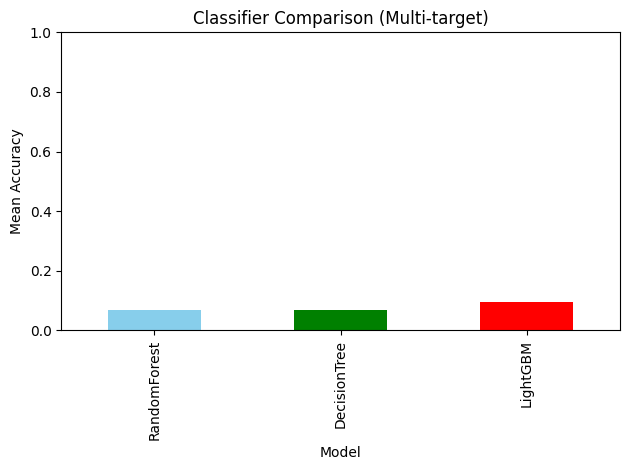

Best classifier: LightGBM. Saved as final_best_classifier.pkl.


In [13]:
#-- COMPARE & SAVE CLASSIFIER ---
results_cls_df = pd.DataFrame(results_cls, columns=['Model', 'Mean Accuracy'])
print('\nClassification Model Mean Accuracies:\n', results_cls_df)
results_cls_df.plot(x='Model', y='Mean Accuracy', kind='bar', legend=False, color=['skyblue', 'green', 'red'])
plt.ylabel('Mean Accuracy')
plt.title('Classifier Comparison (Multi-target)')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'classification_model_comparison.png'))
plt.show()

best_cls_idx = results_cls_df['Mean Accuracy'].idxmax()
best_cls_name = results_cls_df.iloc[best_cls_idx]['Model']
joblib.dump(models_cls[best_cls_name], os.path.join(MODEL_DIR, 'final_best_classifier.pkl'))
print(f"Best classifier: {best_cls_name}. Saved as final_best_classifier.pkl.")

 Multi-Output Regression Models

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

results_reg = {}
models_reg = {}

In [15]:
# --- RANDOM FOREST REGRESSOR ---
rf_reg = MultiOutputRegressor(RandomForestRegressor(random_state=42))
rf_reg.fit(X_train, y_train)
y_pred_rfreg = rf_reg.predict(X_test)
rfreg_mse = mean_squared_error(y_test, y_pred_rfreg, multioutput='raw_values')
rfreg_r2 = r2_score(y_test, y_pred_rfreg, multioutput='raw_values')
print(f"\nRandom Forest Regressor MSE: {rfreg_mse}, R2: {rfreg_r2}")
results_reg['RandomForest'] = r2_score(y_test, y_pred_rfreg)
models_reg['RandomForest'] = rf_reg
joblib.dump(rf_reg, os.path.join(MODEL_DIR, 'rf_regressor_multi.pkl'))



Random Forest Regressor MSE: [1473.7928945    3.44606  ], R2: [0.98148732 0.55430619]


['C:\\My stuff\\Coding\\ML project\\KiranveerSingh_Project\\Models\\rf_regressor_multi.pkl']

In [16]:
#--- DECISION TREE REGRESSOR ---
dt_reg = MultiOutputRegressor(DecisionTreeRegressor(random_state=42))
dt_reg.fit(X_train, y_train)
y_pred_dtreg = dt_reg.predict(X_test)
dtreg_mse = mean_squared_error(y_test, y_pred_dtreg, multioutput='raw_values')
dtreg_r2 = r2_score(y_test, y_pred_dtreg, multioutput='raw_values')
print(f"\nDecision Tree Regressor MSE: {dtreg_mse}, R2: {dtreg_r2}")
results_reg['DecisionTree'] = r2_score(y_test, y_pred_dtreg)
models_reg['DecisionTree'] = dt_reg
joblib.dump(dt_reg, os.path.join(MODEL_DIR, 'decision_tree_reg_multi.pkl'))



Decision Tree Regressor MSE: [3736.33     7.665], R2: [0.95306702 0.00865247]


['C:\\My stuff\\Coding\\ML project\\KiranveerSingh_Project\\Models\\decision_tree_reg_multi.pkl']

In [17]:
# --- LIGHTGBM REGRESSOR ---
lgb_reg = MultiOutputRegressor(lgb.LGBMRegressor(random_state=42))
lgb_reg.fit(X_train, y_train)
y_pred_lgbreg = lgb_reg.predict(X_test)
lgbreg_mse = mean_squared_error(y_test, y_pred_lgbreg, multioutput='raw_values')
lgbreg_r2 = r2_score(y_test, y_pred_lgbreg, multioutput='raw_values')
print(f"\nLightGBM Regressor MSE: {lgbreg_mse}, R2: {lgbreg_r2}")
results_reg['LightGBM'] = r2_score(y_test, y_pred_lgbreg)
models_reg['LightGBM'] = lgb_reg
joblib.dump(lgb_reg, os.path.join(MODEL_DIR, 'lgb_regressor_multi.pkl'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7936
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 44
[LightGBM] [Info] Start training from score 507.125000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

['C:\\My stuff\\Coding\\ML project\\KiranveerSingh_Project\\Models\\lgb_regressor_multi.pkl']


Regression Model Mean R2 Scores:
           Model   Mean R2
0  RandomForest  0.767897
1  DecisionTree  0.480860
2      LightGBM  0.869619


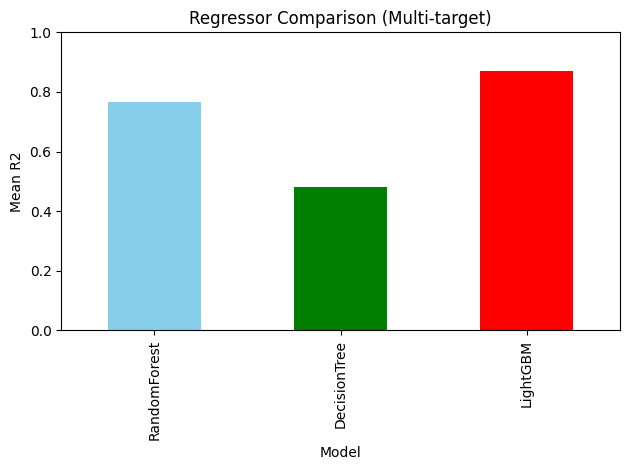

Best regressor: LightGBM. Saved as final_best_regressor.pkl.


In [18]:
# --- COMPARE & SAVE REGRESSOR ---
results_reg_df = pd.DataFrame(list(results_reg.items()), columns=['Model', 'Mean R2'])
print("\nRegression Model Mean R2 Scores:\n", results_reg_df)
results_reg_df.plot(x='Model', y='Mean R2', kind='bar', legend=False, color=['skyblue', 'green', 'red'])
plt.ylabel('Mean R2')
plt.title('Regressor Comparison (Multi-target)')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'regression_model_comparison.png'))
plt.show()

best_reg_idx = results_reg_df['Mean R2'].idxmax()
best_reg_name = results_reg_df.iloc[best_reg_idx]['Model']
joblib.dump(models_reg[best_reg_name], os.path.join(MODEL_DIR, 'final_best_regressor.pkl'))
print(f"Best regressor: {best_reg_name}. Saved as final_best_regressor.pkl.")

In [19]:
import joblib
import os
from sklearn.metrics import accuracy_score, r2_score
import numpy as np

MODEL_DIR = r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models"
# Reload test data as before (make sure X_test and y_test are the same as during training split)
# For example:
# X_test, y_test = ...

# Load the best trained models
best_classifier = joblib.load(os.path.join(MODEL_DIR, 'final_best_classifier.pkl'))
best_regressor = joblib.load(os.path.join(MODEL_DIR, 'final_best_regressor.pkl'))

# --- Evaluate Classifier (Mean Accuracy) ---
y_pred_cls = best_classifier.predict(X_test)
# y_test may be a DataFrame; convert predictions for easy comparison
if isinstance(y_pred_cls, np.ndarray):
    y_pred_cls = np.array(y_pred_cls)
if hasattr(y_test, 'columns'):
    accs = []
    for idx, col in enumerate(y_test.columns):
        accs.append(accuracy_score(y_test[col], y_pred_cls[:, idx]))
    mean_accuracy = np.mean(accs)
else:
    mean_accuracy = accuracy_score(y_test, y_pred_cls)
print(f'Best classifier mean accuracy: {mean_accuracy:.4f}')

# --- Evaluate Regressor (Mean R²) ---
y_pred_reg = best_regressor.predict(X_test)
if hasattr(y_test, 'columns') or isinstance(y_test, pd.DataFrame):
    r2s = []
    for idx, col in enumerate(y_test.columns):
        r2s.append(r2_score(y_test[col], y_pred_reg[:, idx]))
    mean_r2 = np.mean(r2s)
else:
    mean_r2 = r2_score(y_test, y_pred_reg)
print(f'Best regressor mean R²: {mean_r2:.4f}')

# --- Compare and Save Best Model ---
if mean_accuracy >= mean_r2:
    finalbest_model = best_classifier
    model_type = 'Classifier'
    final_score = mean_accuracy
else:
    finalbest_model = best_regressor
    model_type = 'Regressor'
    final_score = mean_r2

joblib.dump(finalbest_model, os.path.join(MODEL_DIR, 'best_of_regression_and_classification.pkl'))
print(f"Final best model type: {model_type}, score: {final_score:.4f}")
print("Final best model saved as models/best_of_regression_and_classification.pkl")


Best classifier mean accuracy: 0.0950
Best regressor mean R²: 0.8696
Final best model type: Regressor, score: 0.8696
Final best model saved as models/best_of_regression_and_classification.pkl


c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import numpy as np

MODEL_DIR = r'C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models'

xgb_clf_dict = {}      # Each target col: {'model': XGBClassifier, 'encoder': LabelEncoder, 'accuracy': float}
all_accuracies = []

for col in y_train.columns:
    # ... LabelEncoder and y_train_enc code as before ...

    # Map test; only evaluate test samples with label seen in train
    y_test_list = list(y_test[col])
    valid_indices = []
    y_test_enc_valid = []

    for idx, label in enumerate(y_test_list):
        if label in le.classes_:
            y_test_enc_valid.append(le.transform([label])[0])
            valid_indices.append(idx)
    y_test_enc_valid = np.array(y_test_enc_valid)

    if len(valid_indices) == 0:
        print(f"Skipping XGBoost for '{col}': No valid test sample with label seen in train.")
        continue

    clf = XGBClassifier(random_state=42, eval_metric='mlogloss')
    clf.fit(X_train, y_train_enc)
    y_pred = clf.predict(X_test)
    y_pred_valid = y_pred[valid_indices]

    acc = accuracy_score(y_test_enc_valid, y_pred_valid)
    print(f"\nXGBoost classifier for {col}: accuracy (on valid test samples) = {acc:.4f}")
    print(classification_report(y_test_enc_valid, y_pred_valid))
    xgb_clf_dict[col] = {
        'model': clf,
        'encoder': le,
        'accuracy': acc
    }
    all_accuracies.append(acc)

mean_acc_cls = np.mean(all_accuracies)
if all_accuracies:
    mean_acc_cls = np.mean(all_accuracies)
    print(f"Mean XGBoost multi-target accuracy (across all valid test samples): {mean_acc_cls:.4f}")
else:
    print("No valid test samples for any target column. Mean accuracy not calculated.")

joblib.dump({'models': xgb_clf_dict, 'mean_accuracy': mean_acc_cls if all_accuracies else None},
            os.path.join(MODEL_DIR, 'xgboost_classifier_percolumn.pkl'))

#For overall accuracy
if all_accuracies:
    mean_acc_cls = np.mean(all_accuracies)
    print(f"Mean XGBoost multi-target accuracy (across all valid test samples): {mean_acc_cls:.4f}")
    # Show overall accuracy at the end for easy reporting
    print(f"\nOverall accuracy of the XGBoost model: {mean_acc_cls:.4f}")
else:
    print("No valid test samples for any target column. Mean accuracy not calculated.")



from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb_reg = MultiOutputRegressor(XGBRegressor(random_state=42))
xgb_reg.fit(X_train, y_train)
y_pred_reg = xgb_reg.predict(X_test)

# Option 1: For regression (use mean R² score)
r2s = [r2_score(y_test[col], y_pred_reg[:, idx]) for idx, col in enumerate(y_test.columns)]
mean_r2 = sum(r2s) / len(r2s)
print(f'XGBoost regressor mean R²: {mean_r2:.4f}')

# Option 2: For comparing as accuracy, round predictions to nearest class/label if appropriate
import numpy as np
y_pred_reg_labels = np.round(y_pred_reg).astype(int)
accs_reg = [accuracy_score(y_test[col], y_pred_reg_labels[:, idx]) for idx, col in enumerate(y_test.columns)]
mean_acc_reg = sum(accs_reg) / len(accs_reg)
print(f'XGBoost regression (rounded) mean accuracy: {mean_acc_reg:.4f}')

# Save the regressor model
joblib.dump(xgb_reg, os.path.join(MODEL_DIR, 'xgboost_regressor_multi.pkl'))




# After running both models:

# Decide which metric to use; for classification, use mean_acc_cls; for regression, use mean_acc_reg
if mean_acc_cls >= mean_acc_reg:
    best_model = xgb_clf
    best_type = "XGBoost Classifier"
    best_score = mean_acc_cls
else:
    best_model = xgb_reg
    best_type = "XGBoost Regressor"
    best_score = mean_acc_reg

joblib.dump(best_model, os.path.join(MODEL_DIR, 'xgboost_best_model.pkl'))
print(f"Best XGBoost model: {best_type}, Score: {best_score:.4f}")
print("Model saved as models/xgboost_best_model.pkl")

final_best_score=best_score





Skipping XGBoost for 'Deficiency_Features_enc': No valid test sample with label seen in train.
Skipping XGBoost for 'Deficiency_Count': No valid test sample with label seen in train.
No valid test samples for any target column. Mean accuracy not calculated.
No valid test samples for any target column. Mean accuracy not calculated.


c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


XGBoost regressor mean R²: 0.7984
XGBoost regression (rounded) mean accuracy: 0.1275
Best XGBoost model: XGBoost Regressor, Score: 0.1275
Model saved as models/xgboost_best_model.pkl


c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [27]:
if final_best_score >= mean_r2:
    final_model = best_model
    model_type = best_type
else:
    final_model = best_regressor
    model_type = "Decision Tree Regressor"

joblib.dump(final_model, os.path.join(MODEL_DIR, 'finalbest.pkl'))

print(f"Final best model is: {model_type}. Saved as finalbest.pkl.")


Final best model is: Decision Tree Regressor. Saved as finalbest.pkl.
